# Portada

**Universidad Autonoma de Nuevo Leon**

**Maestria de Ciencia de Datos**

**Aprendizaje Automatico**

Irving Daniel Estrada Lopez

Alumnos:
* Andrea Linette Mezquita Gomez
* Carlos Enrique Cepeda Fuentes
* Miguel Alejandro Blanco Rios

# Librerias

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer, PowerTransformer, OneHotEncoder, StandardScaler

# Carga de Datos

In [2]:
# --- Primer dataset (cronologico de contenido) ---
online_retail_ii = pd.read_excel(r"..\data\raw\online_retail_ii.xlsx")

online_retail_ii.rename(columns={
    "Price" : "UnitPrice",
    "Customer ID" : "CustomerID"
}, inplace=True)

print(online_retail_ii.shape)
online_retail_ii.head(5)

(525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# --- Segundo dataset (cronologico de contenido) ---
online_retail = pd.read_excel(r"..\data\raw\online_retail.xlsx")

online_retail.rename(columns={
    "InvoiceNo" : "Invoice"
}, inplace=True)

print(online_retail.shape)
online_retail.head(5)

(541909, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Procesamiento de Datos

In [ ]:
# Se omiten las ordenes de compra que ya estan en el primer dataset
online_retail = online_retail[~online_retail["Invoice"].isin(online_retail_ii["Invoice"].unique())]

# --- Union de dataset ---
df_raw = pd.concat([
    online_retail_ii,
    online_retail
])
del online_retail_ii, online_retail

# Ordenamiento de dataset
df_raw.sort_values(by=["InvoiceDate","Invoice","StockCode"], inplace=True)

cols_str = ["Invoice","StockCode","Description","Country"]
for col in cols_str:
    df_raw[col] = df_raw[col].astype(str)

cols_float = ["Quantity","UnitPrice","CustomerID"]
for col in cols_float:
    df_raw[col] = df_raw[col].astype(float)

df_raw["InvoiceDate"] = pd.to_datetime(df_raw["InvoiceDate"])

# Imprimir dimensiones y filas ejemplo
print( df_raw.shape )
df_raw.head()

(1044847, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10.0,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24.0,2009-12-01 07:45:00,1.65,13085.0,United Kingdom


In [6]:
df = df_raw.copy()
del df_raw

df.dropna(subset="CustomerID", inplace=True)
df.sort_values(by=["CustomerID","InvoiceDate","Invoice","StockCode"], inplace=True)
df.reset_index(drop=True, inplace=True)

df["Sales"] = df["Quantity"] * df["UnitPrice"]

print( df.shape )
df.head()

(809560, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,491725,TEST001,This is a test product.,10.0,2009-12-14 08:34:00,4.5,12346.0,United Kingdom,45.0
1,491742,TEST001,This is a test product.,5.0,2009-12-14 11:00:00,4.5,12346.0,United Kingdom,22.5
2,491744,TEST001,This is a test product.,5.0,2009-12-14 11:02:00,4.5,12346.0,United Kingdom,22.5
3,492718,TEST001,This is a test product.,5.0,2009-12-18 10:47:00,4.5,12346.0,United Kingdom,22.5
4,492722,TEST002,This is a test product.,1.0,2009-12-18 10:55:00,1.0,12346.0,United Kingdom,1.0


In [7]:
df_prod = df.copy()

clientes_de_pruebas = df_prod[df_prod["StockCode"].str.casefold().str.contains('test')]["CustomerID"].drop_duplicates()
df_prod = df_prod[~df_prod["CustomerID"].isin(clientes_de_pruebas)]

df_prod_compras = df_prod[df_prod["Quantity"]>=0]

df_prod_devolucion = df_prod[df_prod["Quantity"]<0]

In [27]:
df_prod = df.copy()

clientes_de_pruebas = df_prod[df_prod["StockCode"].str.casefold().str.contains('test')]["CustomerID"].drop_duplicates()
df_prod = df_prod[~df_prod["CustomerID"].isin(clientes_de_pruebas)]

df_prod_compras = df_prod[df_prod["Quantity"]>=0]

df_prod_devolucion = df_prod[df_prod["Quantity"]<0]

# -- Comrpas reales --
df_customer = df_prod_compras.groupby(by=["CustomerID"]).agg({
    "Country" : pd.Series.nunique,
    "InvoiceDate" : ["min","max"],
    "Sales" : "sum",
    "Quantity" : "sum",
    "Invoice" : pd.Series.nunique,
    "UnitPrice" : "max",
    "StockCode" : pd.Series.nunique
})
df_customer.columns = ["Paises Distintos","Date_Min","Date_Max",  "Sales","Quantity","Compras","Precio_Max","Productos Distintos"]
df_customer.reset_index(inplace=True)


df_customer_top_country = df_prod_compras.groupby(by=["CustomerID","Country"])["Invoice"].nunique().rename("Compras").reset_index().sort_values(by=["CustomerID","Compras"], ascending=False)

df_customer_top_country["rn"] = df_customer_top_country.groupby(by="CustomerID")["CustomerID"].cumcount()
df_customer_top_country = df_customer_top_country[df_customer_top_country["rn"]==0].drop(columns=["rn","Compras"]).rename(columns={"Country":"Pais Principal"})

df_customer = pd.merge(
    df_customer,
    df_customer_top_country,
    on="CustomerID",
    how="left"
)

df_customer.set_index("CustomerID", inplace=True)

df_customer["Permanencia"] = np.round(( df_customer["Date_Max"] - df_customer["Date_Min"] ).dt.total_seconds()/60/60/24, 0) + 1

df_customer["Canasta_Prom"] = df_customer["Quantity"]/df_customer["Compras"]
df_customer["Ticket_Prom"] = df_customer["Sales"]/df_customer["Compras"]
df_customer["Precio_Prom"] = df_customer["Sales"]/df_customer["Quantity"]


# -- Devoluciones --

df_customer_devolucion = df_prod_devolucion.groupby(by="CustomerID")["Invoice"].nunique().rename("Devoluciones").reset_index()


# -- Union de datos --

df_customer = pd.merge(
    df_customer,
    df_customer_devolucion,
    on="CustomerID",
    how="left"
)
df_customer.loc[df_customer["Devoluciones"].isna(), "Devoluciones"] = 0

df_customer["Pct_Devoluciones"] = df_customer["Devoluciones"] / df_customer["Compras"]

df_customer["Pais Principal"] = df_customer["Pais Principal"].astype("category")

df_customer = df_customer.set_index("CustomerID")[[
    "Pais Principal", "Paises Distintos",
    "Permanencia",
    "Compras", 
    "Canasta_Prom", "Ticket_Prom", "Precio_Prom", "Precio_Max",
    "Productos Distintos",
    "Pct_Devoluciones"
]]

print( df_customer.shape )
df_customer.head()

(5876, 10)


,Pais Principal,Paises Distintos,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones
CustomerID,,,,,,,,,,
12347.0,Iceland,1,403.0,8,370.875,615.19125,1.658756,12.75,126,0.00
12348.0,Finland,1,364.0,5,542.800,403.88000,0.744068,40.00,25,0.00
12349.0,Italy,1,572.0,4,406.000,1107.17250,2.727026,300.00,138,0.25
12350.0,Norway,1,1.0,1,197.000,334.40000,1.697462,40.00,17,0.00
12351.0,Unspecified,1,1.0,1,261.000,300.93000,1.152989,12.75,21,0.00


# Exploracion de Datos

In [28]:
df_customer.describe().round(2)

,Paises Distintos,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones
count,5876.00,5876.00,5876.00,5876.00,5876.00,5876.00,5876.00,5876.00,5876.00
mean,1.00,274.29,6.29,242.88,371.56,7.15,37.33,82.01,0.19
std,0.05,259.00,13.02,1331.92,521.42,176.26,303.09,116.50,0.33
min,1.00,1.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00
25%,1.00,1.00,1.00,91.78,178.35,1.43,8.50,19.00,0.00
50%,1.00,221.50,3.00,155.00,280.92,1.83,12.75,45.00,0.00
75%,1.00,513.00,7.00,258.00,415.91,2.35,16.95,103.00,0.28
max,2.00,739.00,398.00,87167.00,14844.77,10953.50,10953.50,2550.00,4.00


**Comentarios:**

* **Permanencia :** El 25% de los clientes compran en un solo día. El cliente mediano dura 7 meses y medio. Si hay clientes vitalicios dentro del conjunto de datos analizado.
* **Compras :** El cliente con mas compras es 398, mientras el 75% llega hasta 7. La mitad de los clientes compran no más de 3 veces en el periodo de 2 años analizado.
* **Canasta promedio :** El cliente con mas unidades promedio por compra es 87167, mientras el 75% llega hasta 258. La mitad de los clientes compran no más de 155 unidades promedio por compra.
* **Ticket promedio :** El cliente con mayor gasto promedio por compra es $14,844, mientras el 75% llega hasta $416. La mitad de los clientes gastan no más de $281 promedio por compra.
* **Precio promedio :** El cliente que compra en promedio los productos mas caros gasta $10,953 por producto, mientras el 75% llega hasta $2.35. La mitad no gasta más de $1.83 en un producto.
* **Precio maximo :** El clinete que compra el producto más caro es de $10,953, mientras el 75% llega hasta $16.9. La mitad no gasta más de $12.7 en su producto más caro.
* **Producto distintos :** Los clientes usualmente compran hasta 103 productos distintos en el percentil 75; mientras el que más productos distintos compra tiene 2,550.
* **Porcentaje de devoluciones :** El maximo es 400%, la mitad no tienen ninguna devolucion y el 75% llega hasta 28%.

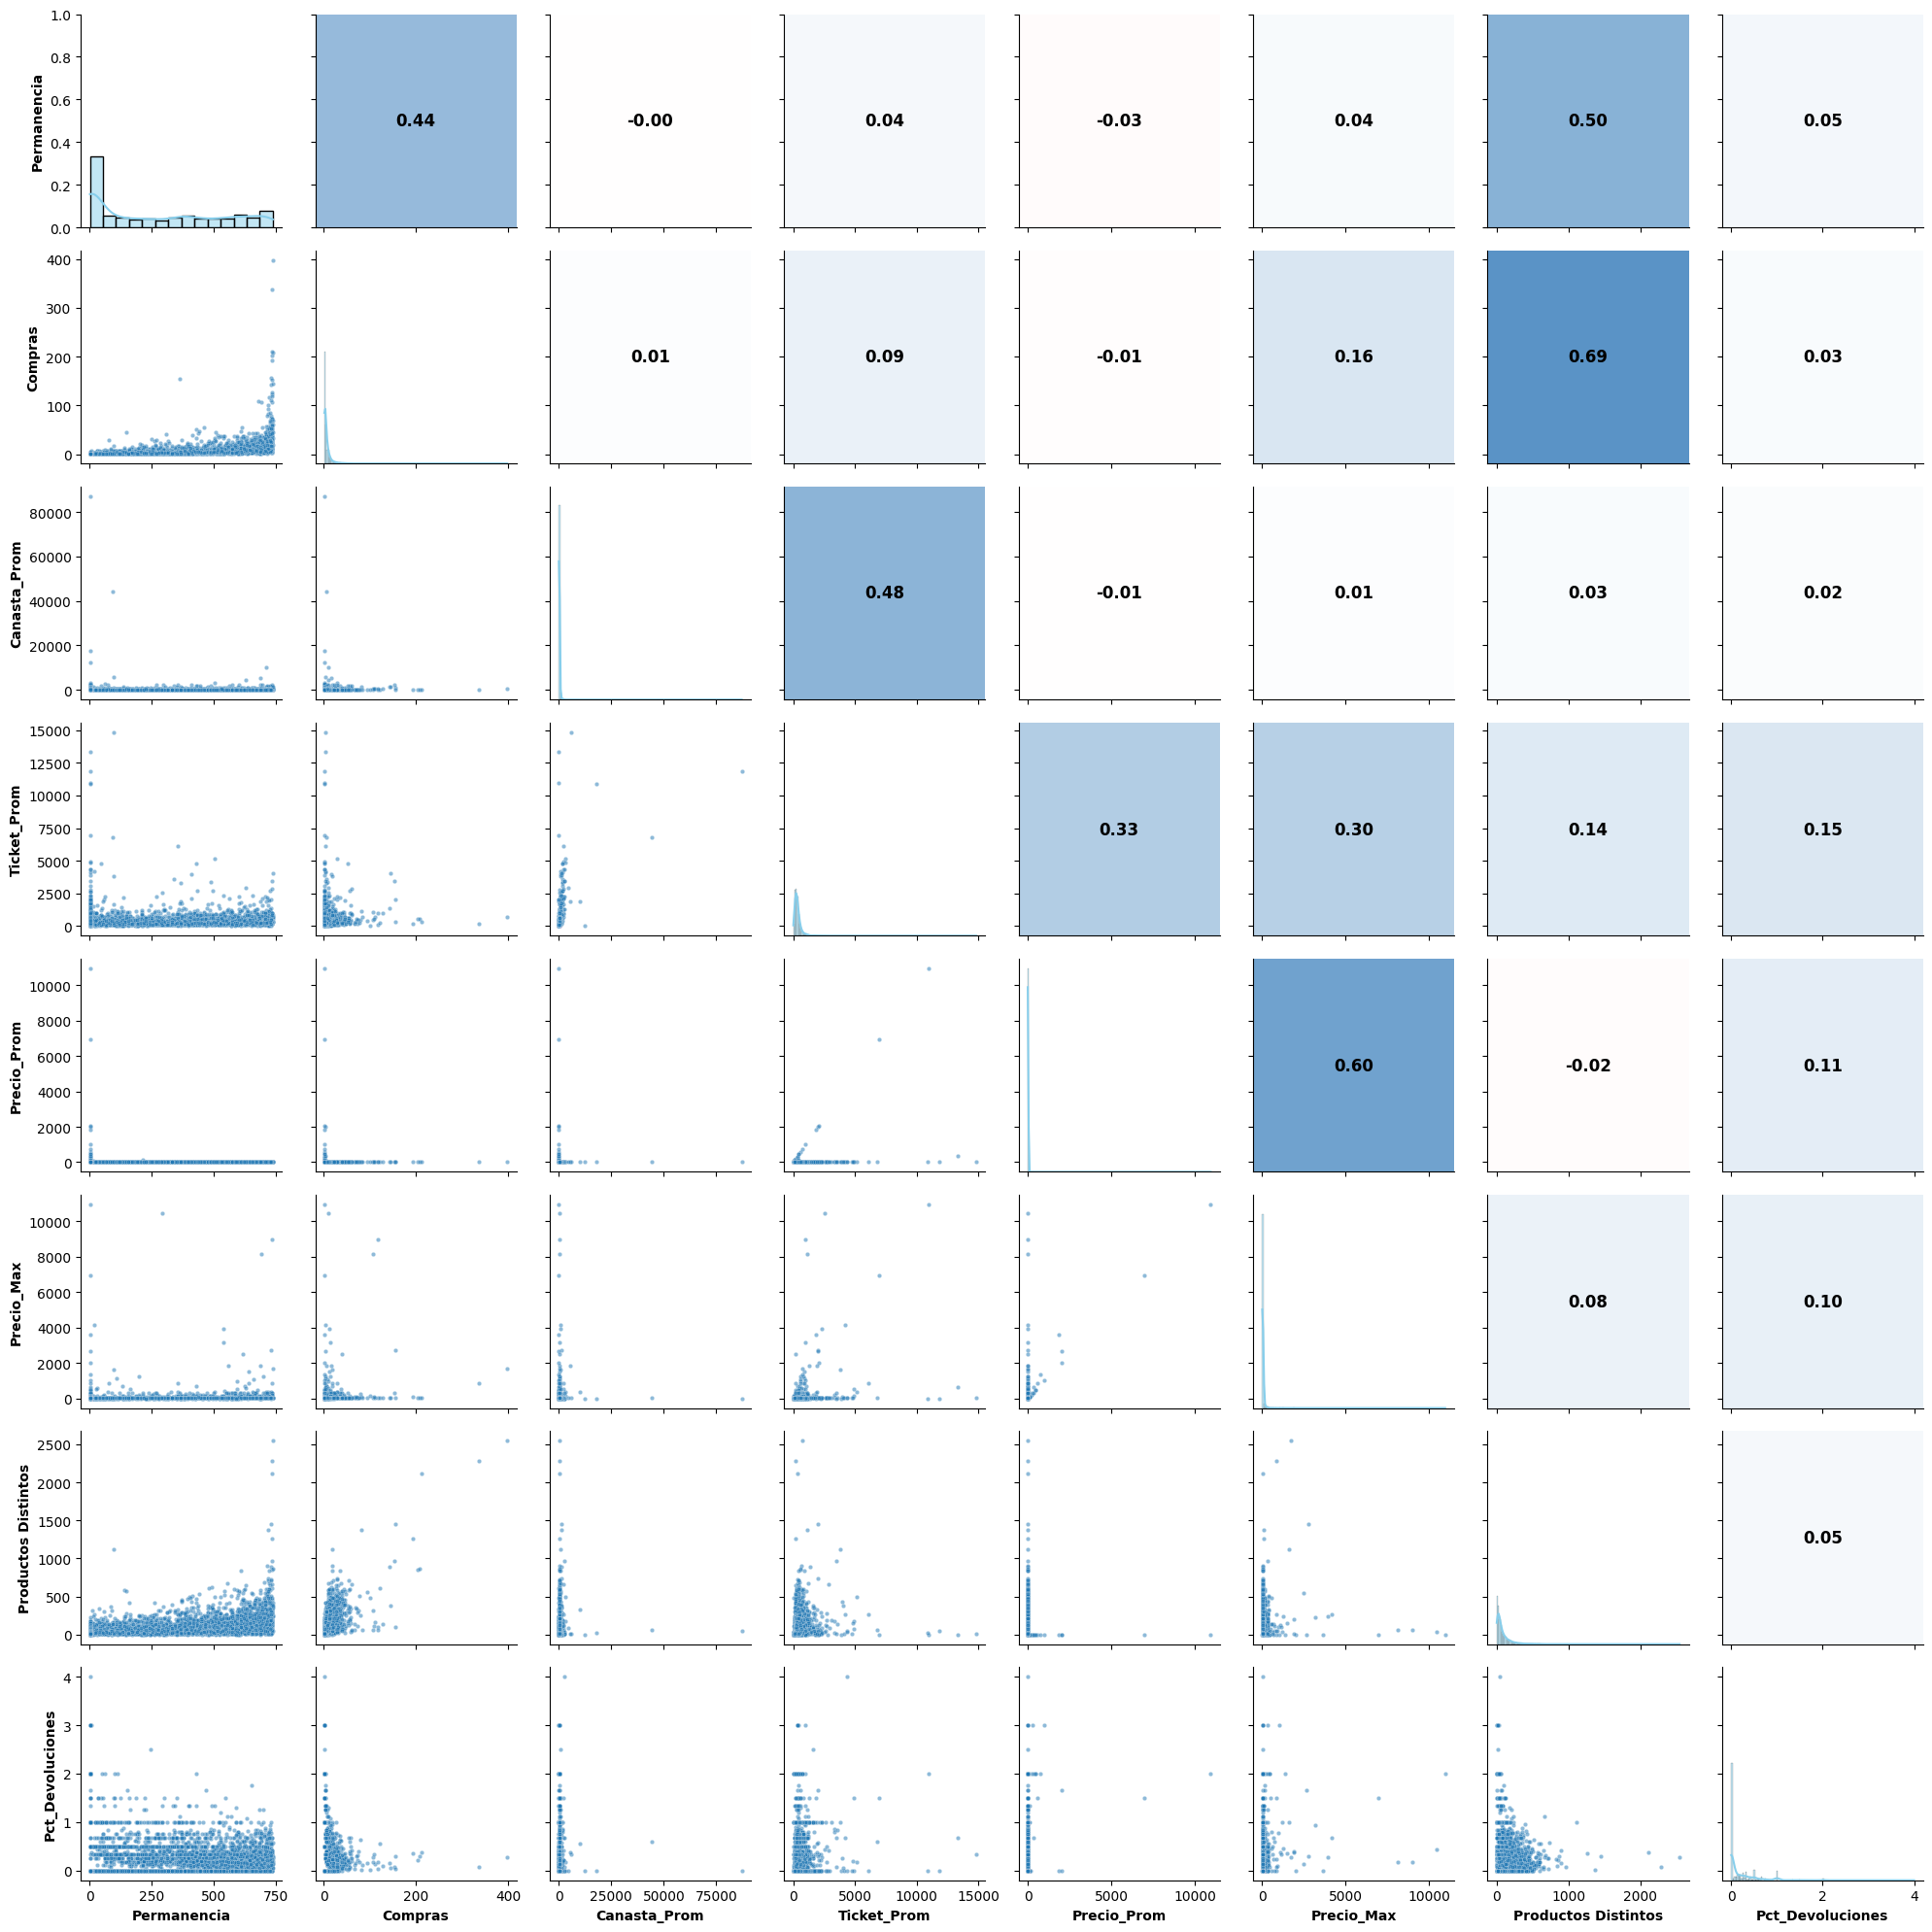

In [35]:
# Grafica correlacion de pearson y de dispersion en triangulo superior

# variables numericas
df_num = df_customer[[
    "Permanencia",
    "Compras", 
    "Canasta_Prom", "Ticket_Prom", "Precio_Prom", "Precio_Max",
    "Productos Distintos",
    "Pct_Devoluciones"
]]

cmap_corr = mcolors.LinearSegmentedColormap.from_list(
    'custom_corr', ['#ef796d', '#ffffff', '#1164ad']
)

# funcion para anotar la correlacion de pearson en el triangulo superior
def corrfunc(x, y, **kws):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()

    color_norm = (r + 1) / 2
    ax.set_facecolor(cmap_corr(color_norm))

    ax.annotate(
        f'{r:.2f}',
        xy=(0.5, 0.5),
        xycoords=ax.transAxes,
        ha='center',
        va='center',
        fontsize=12,
        weight='bold',
    )


g = sns.PairGrid(df_num)

# scatter plot en triangulo inferior
g.map_lower(sns.scatterplot, alpha=0.5, s=10)

# histograma/KDE en diagonal
g.map_diag(sns.histplot, kde=True, color='skyblue')

# correlacion en triangulo superior
g.map_upper(corrfunc)

for ax in g.axes.flat:
  if ax is not None:
    xlabel = ax.get_xlabel()
    ylabel = ax.get_ylabel()
    if xlabel:
      ax.set_xlabel(xlabel, fontweight='bold')
    if ylabel:
      ax.set_ylabel(ylabel, fontweight='bold')

plt.tight_layout()
plt.show()

Aplicamos transformacion log normal dado que los historgamas no parecen normales y afectaria el reusltados de modelos de densidad

In [38]:
df_customer_transformed = df_customer.copy()
transformers = dict()

cols_log_normal = [
    "Compras", 
    "Canasta_Prom", "Ticket_Prom", "Precio_Prom", "Precio_Max",
    "Productos Distintos"
]
for col in cols_log_normal:    
    transformer = FunctionTransformer(func=np.log1p, inverse_func=np.expm1, validate=True)
    transformer.fit(df_customer_transformed[[col]].to_numpy())
    
    transformers[col] = transformer

cols_pw_normal = [
    "Pct_Devoluciones"
]
for col in cols_pw_normal:    
    transformer = PowerTransformer(method='yeo-johnson', standardize=False)
    transformer.fit(df_customer_transformed[[col]].to_numpy())
    
    transformers[col] = transformer


for col in [*cols_log_normal, *cols_pw_normal]:
    df_customer_transformed[col] = transformers[col].transform(df_customer_transformed[[col]].to_numpy())

df_customer_transformed.describe()

,Paises Distintos,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones
count,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000,5876.000000
mean,1.002212,274.287270,1.549355,4.999872,5.621071,1.090667,2.686656,3.760129,0.065266
std,0.046988,258.997643,0.809555,0.921822,0.732573,0.465508,0.883648,1.219075,0.081191
min,1.000000,1.000000,0.693147,0.693147,0.000000,0.000000,0.000000,0.693147,-0.000000
25%,1.000000,1.000000,0.693147,4.530256,5.189364,0.887146,2.251292,2.995732,-0.000000
50%,1.000000,221.500000,1.386294,5.049856,5.641640,1.040241,2.621039,3.828641,-0.000000
75%,1.000000,513.000000,2.079442,5.556828,6.032868,1.208729,2.887590,4.644391,0.147073
max,2.000000,739.000000,5.988961,11.375593,9.605470,9.301506,9.301506,7.844241,0.217507


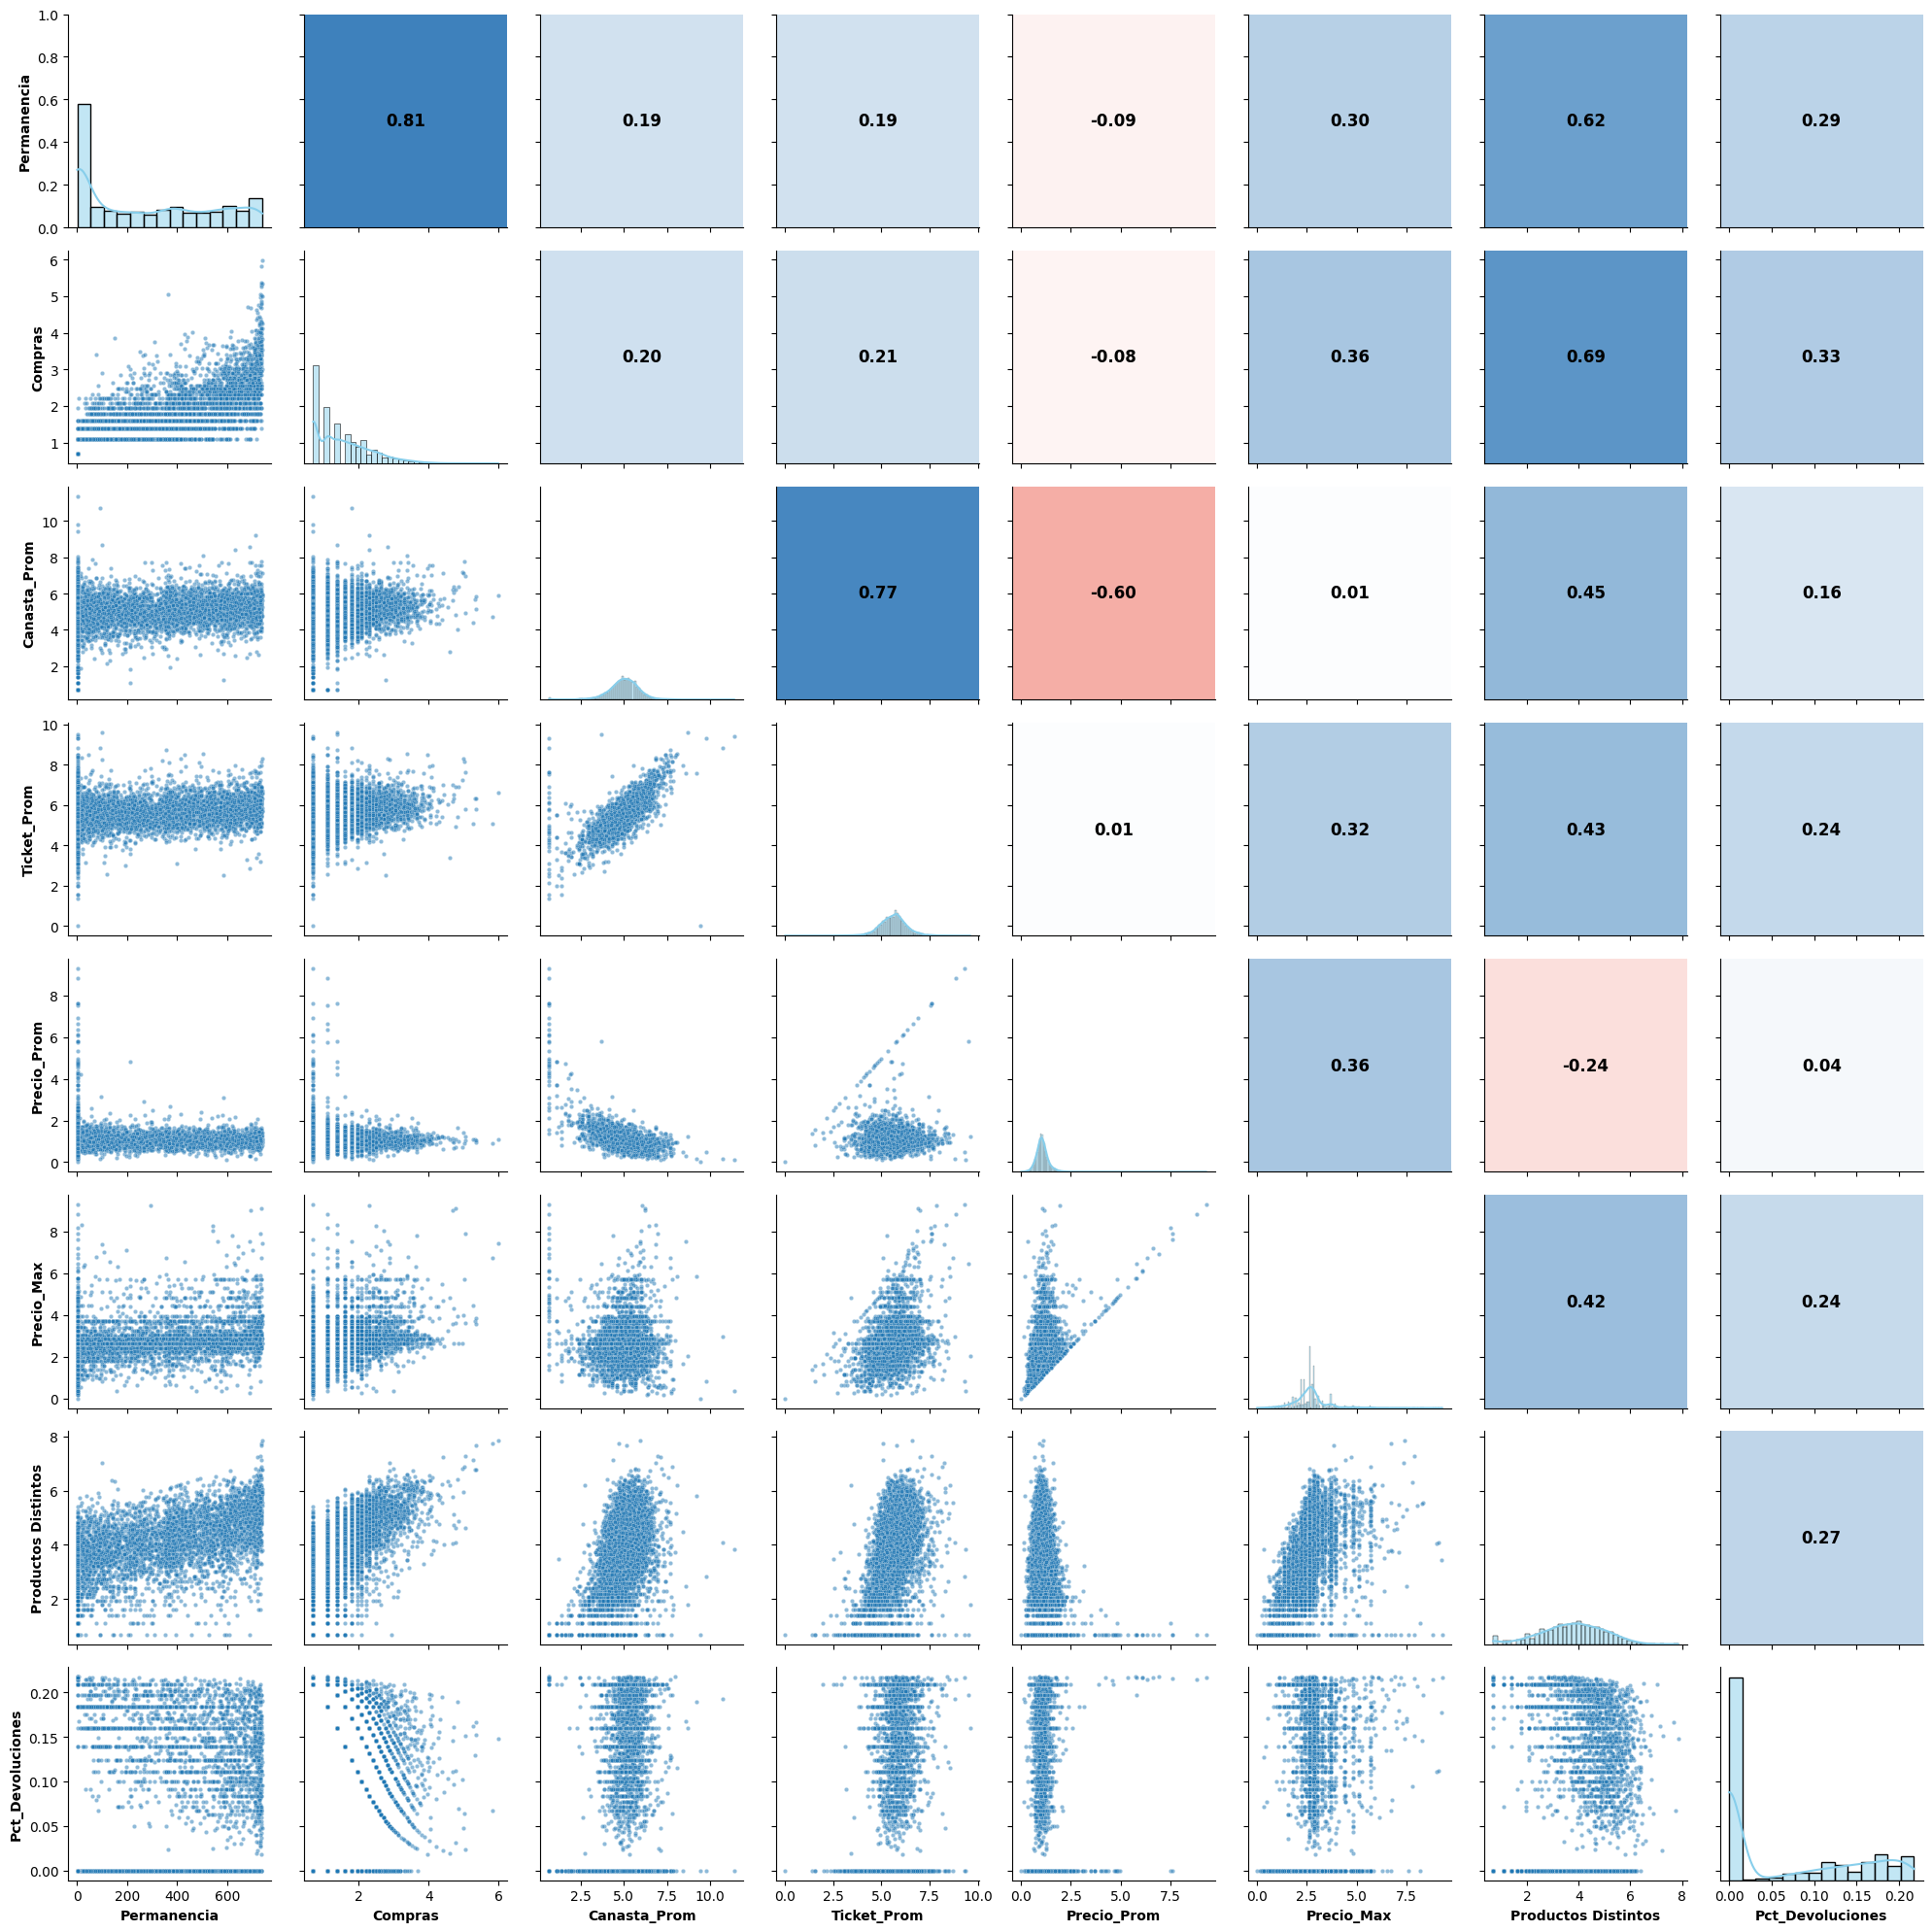

In [39]:
# Grafica correlacion de pearson y de dispersion en triangulo superior

# variables numericas
df_num = df_customer_transformed[[
    "Permanencia",
    "Compras", 
    "Canasta_Prom", "Ticket_Prom", "Precio_Prom", "Precio_Max",
    "Productos Distintos",
    "Pct_Devoluciones"
]]

cmap_corr = mcolors.LinearSegmentedColormap.from_list(
    'custom_corr', ['#ef796d', '#ffffff', '#1164ad']
)

# funcion para anotar la correlacion de pearson en el triangulo superior
def corrfunc(x, y, **kws):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()

    color_norm = (r + 1) / 2
    ax.set_facecolor(cmap_corr(color_norm))

    ax.annotate(
        f'{r:.2f}',
        xy=(0.5, 0.5),
        xycoords=ax.transAxes,
        ha='center',
        va='center',
        fontsize=12,
        weight='bold',
    )


g = sns.PairGrid(df_num)

# scatter plot en triangulo inferior
g.map_lower(sns.scatterplot, alpha=0.5, s=10)

# histograma/KDE en diagonal
g.map_diag(sns.histplot, kde=True, color='skyblue')

# correlacion en triangulo superior
g.map_upper(corrfunc)

for ax in g.axes.flat:
  if ax is not None:
    xlabel = ax.get_xlabel()
    ylabel = ax.get_ylabel()
    if xlabel:
      ax.set_xlabel(xlabel, fontweight='bold')
    if ylabel:
      ax.set_ylabel(ylabel, fontweight='bold')

plt.tight_layout()
plt.show()

**Comentarios:**

* **Correlaciones**
    * Compras X Permanencia : Relacion positiva alta de +0.81. A mayor cantidad de tiempo como cliente, mayor la cantidad de compras que se realizan.
    * Compras X Productos Distintos: Relacion positiva alta de +0.69. A mayor cantidad de compras, mayor variedad de productos comprados.
    * Canasta promedio X Ticket promedio : Relacion positiva alta de +0.77. A mayor cantidad de unidades compradas, mayor el valor promedio de compra.
    * Canasta promedio X Precio promedio : Relacion negativa alta de -0.60. A menor precio, mayor cantidad de unidades compradas.

* **Distribuciones**
    * Tras la transofrmacion, canasta promedio, ticket promedio, precio promedio y productos distintos son aparenetemnete normales

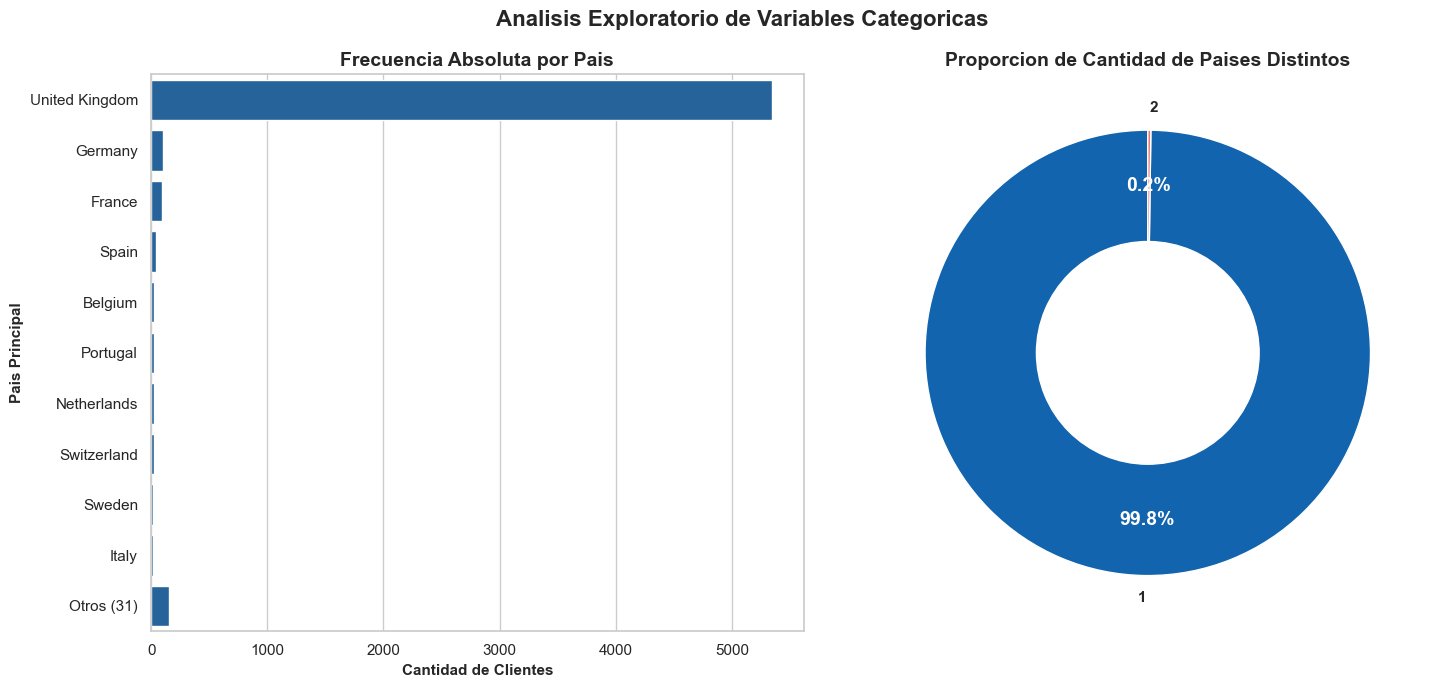

In [32]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

fig.suptitle(
    'Analisis Exploratorio de Variables Categoricas',
    fontsize=16,
    fontweight='bold',
    y=0.98,  # Ajusta la posición vertical (cerca de 1.0 queda arriba del todo)
)

cat_counts = df_customer_transformed['Pais Principal'].value_counts().sort_values(ascending=False)
cat_counts = pd.concat([
    cat_counts.iloc[:10],
    pd.Series([cat_counts.iloc[10:].sum()],name="count", index=[f"Otros ({cat_counts.iloc[10:].shape[0] :0,.0f})"])
])

sns.barplot(
    x=cat_counts.values,
    y=cat_counts.index,
    ax=axes[0],
    order=cat_counts.index,
    color="#1164ad",
    # palette='Blues_r',
    # hue=cat_counts.index,
    # hue_order=cat_counts.index,
    legend=False,
    width=0.8,
)
axes[0].set_title(
    'Frecuencia Absoluta por Pais', fontweight='bold', fontsize=14
)
axes[0].set_xlabel('Cantidad de Clientes', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Pais Principal', fontweight='bold', fontsize=11)



market_counts = df_customer_transformed["Paises Distintos"].value_counts()
labels = ['1', '2']
colors = ['#1164ad', '#ef796d']

# pctdistance fuera del círculo (ej. 1.2 o 1.25)
wedges, texts, autotexts = axes[1].pie(
    market_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.5, edgecolor='w'),
    pctdistance=.75,
)

# Estilar textos y porcentajes fuera
for text in texts:
  text.set_fontsize(11)
  text.set_weight('bold')

for autotext in autotexts:
  autotext.set_fontsize(14)
  autotext.set_weight('bold')
  autotext.set_color('#ffffff')

axes[1].set_title(
    'Proporcion de Cantidad de Paises Distintos', fontweight='bold', fontsize=14
)



plt.tight_layout()
plt.show()
sns.reset_defaults()

**Comentarios:**

* **Pais principal :** El 91% de los clientes hicieron la mayoria de sus compras en UK. El resto se distribuye en los otro 40 paises diferentes.
* **Paises Distintos :** El 99.8% de los clientes hicieron todas sus compras en un solo pais. Y el restante, lo hizo en 2.

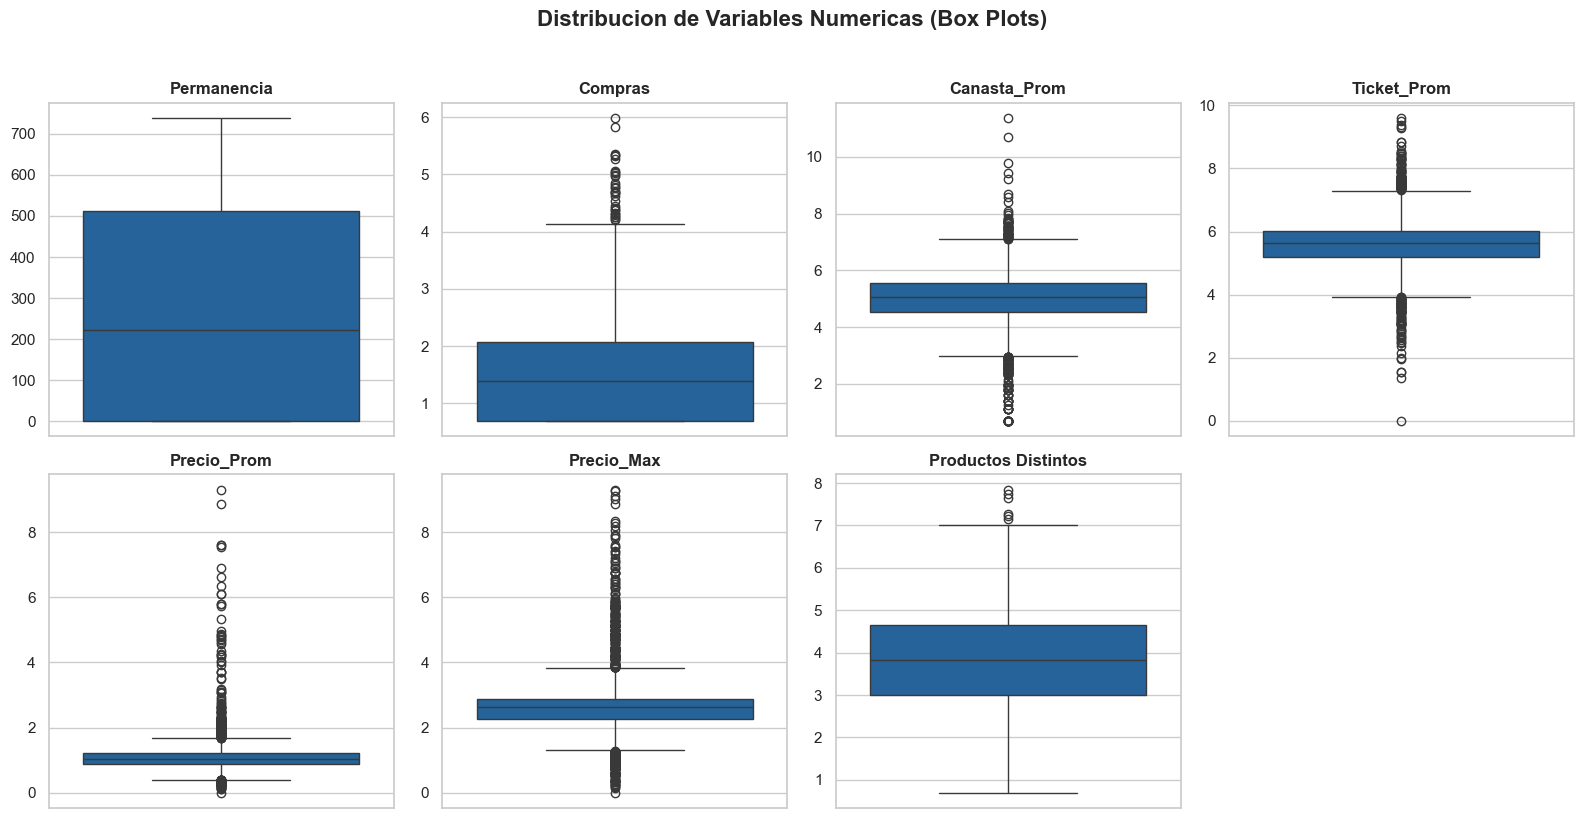

In [33]:
cols_boxplot = [
    "Permanencia",
    "Compras",
    "Canasta_Prom", "Ticket_Prom", "Precio_Prom", "Precio_Max",
    "Productos Distintos"
]
 
n_cols = 4
n_rows = int(np.ceil(len(cols_boxplot) / n_cols))
 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()
 
fig.suptitle(
    "Distribucion de Variables Numericas (Box Plots)",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
 
for ax, col in zip(axes, cols_boxplot):
    sns.boxplot(y=df_customer_transformed[col], ax=ax, color="#1164ad")
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("")
 
for ax in axes[len(cols_boxplot):]:
    ax.axis("off")
 
plt.tight_layout()
plt.show()
sns.reset_defaults()

# Preprocesamiento

In [41]:
df_customer_transformed["Comprador Local"] = (df_customer_transformed["Pais Principal"]=='United Kingdom').astype(float)
df_customer_transformed["Nomada"] = (df_customer_transformed["Paises Distintos"]>1).astype(float)

df_customer_transformed

,Pais Principal,Paises Distintos,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones,Comprador Local,Nomada
CustomerID,,,,,,,,,,,,
12347.0,Iceland,1,403.0,2.197225,5.918558,6.423557,0.977858,2.621039,4.844187,-0.000000,0.0,0.0
12348.0,Finland,1,364.0,1.791759,6.298582,6.003591,0.556220,3.713572,3.258097,-0.000000,0.0,0.0
12349.0,Italy,1,572.0,1.609438,6.008813,7.010468,1.315611,5.707110,4.934474,0.139574,0.0,0.0
12350.0,Norway,1,1.0,0.693147,5.288267,5.815324,0.992311,3.713572,2.890372,-0.000000,0.0,0.0
12351.0,Unspecified,1,1.0,0.693147,5.568345,5.710195,0.766857,2.621039,3.091042,-0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
18283.0,United Kingdom,1,656.0,3.135494,4.379182,4.831454,0.947456,2.830268,5.866468,-0.000000,1.0,0.0
18284.0,United Kingdom,1,1.0,0.693147,6.204558,6.137036,0.659888,3.931826,3.367296,0.208634,1.0,0.0
18285.0,United Kingdom,1,1.0,0.693147,4.983607,6.059123,1.372405,3.931826,2.564949,-0.000000,1.0,0.0


In [42]:
# --- Definimos las columnas numéricas continuas ---
columnas_numericas = ['Permanencia', 'Compras', 'Canasta_Prom', 'Ticket_Prom',
                       'Precio_Prom', 'Precio_Max', 'Productos Distintos',
                       'Pct_Devoluciones']
 
# --- Escalamos solo las numéricas continuas ---
scaler = StandardScaler()
df_num_escalado = pd.DataFrame(
    scaler.fit_transform(df_customer_transformed[columnas_numericas]),
    columns=columnas_numericas,
    index=df_customer_transformed.index
)

df_cat_escalado = df_customer_transformed[["Comprador Local","Nomada"]]*4
 
# --- Dataset final para los modelos ---
df_final = pd.concat([df_num_escalado, df_cat_escalado], axis=1)
 
print(df_final.shape)
df_final.head()

(5876, 10)


,Permanencia,Compras,Canasta_Prom,Ticket_Prom,Precio_Prom,Precio_Max,Productos Distintos,Pct_Devoluciones,Comprador Local,Nomada
CustomerID,,,,,,,,,,
12347.0,0.497007,0.800347,0.996682,1.095527,-0.242354,-0.074263,0.889322,-0.803925,0.0,0.0
12348.0,0.346414,0.299455,1.408970,0.522203,-1.148191,1.162232,-0.411849,-0.803925,0.0,0.0
12349.0,1.149578,0.074223,1.094601,1.896758,0.483263,3.418458,0.963390,0.915303,0.0,0.0
12350.0,-1.055263,-1.057718,0.312880,0.265187,-0.211304,1.162232,-0.713517,-0.803925,0.0,0.0
12351.0,-1.055263,-1.057718,0.616736,0.121669,-0.695665,-0.074263,-0.548894,-0.803925,0.0,0.0


# Modelo

# Evaluacion